In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import json
import pickle
import os
import astropy.io.fits as fits
from astropy.table import Table


def confidence_ellipse(val, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    

    eig = np.linalg.eig(cov)
    
    # Calculating the standard deviation of x from

    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = val[0]

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = val[1]

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)


# Plots after retrieving data

## retrieve Data

In [31]:
path = "/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/data_2003_SE/"
os.chdir(path)
names = np.array(os.listdir())
names.sort()
data = np.zeros((0,2))
errors = np.zeros((0,2))
cov = np.zeros((0,2,2))
for result in names:
    errors = np.vstack((errors, np.sqrt(np.diag(np.loadtxt(result + "/fit_cov.txt")))))
    cov = np.vstack((cov, np.loadtxt(result + "/fit_cov.txt").reshape(1,2,2)))
    data = np.vstack((data, np.loadtxt(result + "/fit_val.txt")))
    

## Plot the parameter space

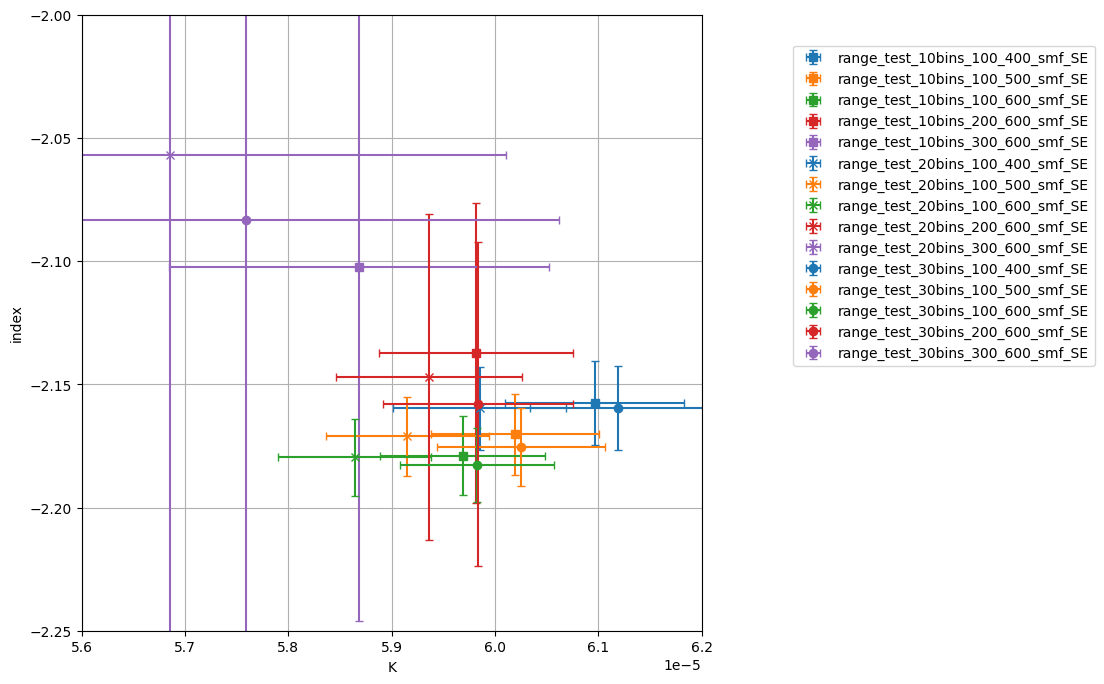

In [32]:
SHOW_30BINS = True
SHOW_20BINS = True
SHOW_10BINS = True


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.grid()


color_index = 0

skip = [
    "range_test_30bins_200_500_smf_SE",
    "range_test_20bins_200_500_smf_SE",
    "range_test_10bins_200_500_smf_SE",
]

colors = [
    "C0",
    "C1",
    "C2",
    "C3",
    "C4",
]

for i, name in enumerate(names):
    if "30bins" in name and name not in skip and SHOW_30BINS:
        ax.errorbar(data[i, 0], data[i, 1], xerr=errors[i, 0], yerr=errors[i, 1], fmt='o', label=name, c=colors[color_index%5], capsize=3)
        color_index += 1
    if "20bins" in name and name not in skip and SHOW_20BINS:
        ax.errorbar(data[i, 0], data[i, 1], xerr=errors[i, 0], yerr=errors[i, 1], fmt='x', label=name, c=colors[color_index%5], capsize=3)
        color_index += 1
    if "10bins" in name and name not in skip and SHOW_10BINS:
        ax.errorbar(data[i, 0], data[i, 1], xerr=errors[i, 0], yerr=errors[i, 1], fmt='s', label=name, c=colors[color_index%5], capsize=3)
        color_index += 1


ax.set_ylabel(r"index")
ax.set_xlabel(r"K")

ax.set_xlim([5.6e-5, 6.2e-5])
ax.set_ylim([-2.25, -2.0])
fig.legend(bbox_to_anchor=(1.4, 0.85))

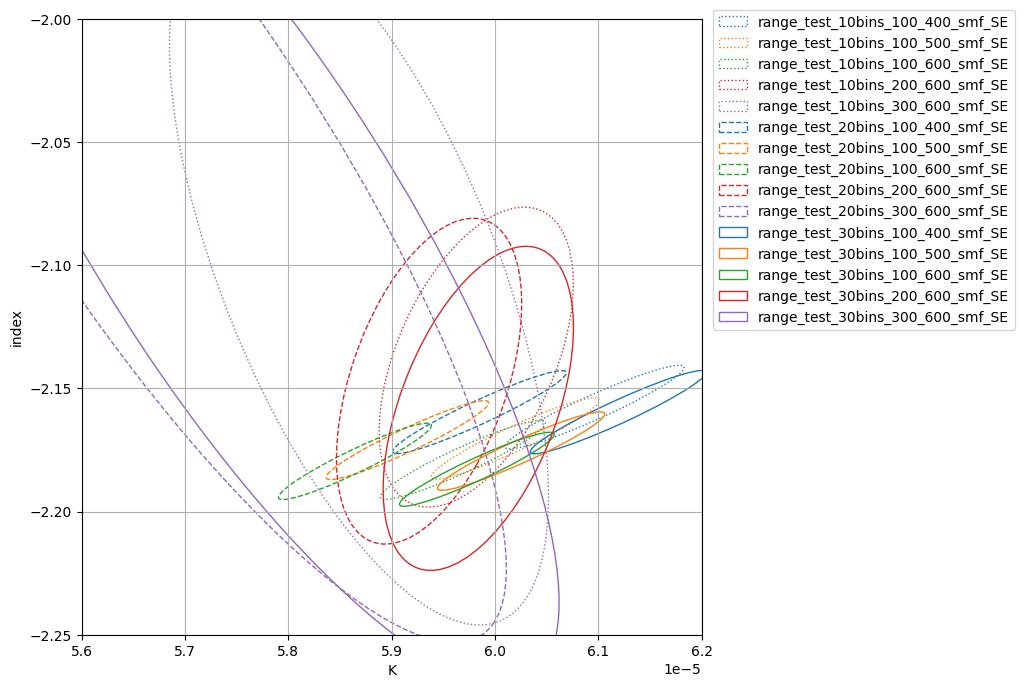

In [33]:
SHOW_30BINS = True
SHOW_20BINS = True
SHOW_10BINS = True


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.grid()


color_index = 0

skip = [
    "range_test_30bins_200_500_smf_SE",
    "range_test_20bins_200_500_smf_SE",
    "range_test_10bins_200_500_smf_SE",
]

colors = [
    "C0",
    "C1",
    "C2",
    "C3",
    "C4",
]

for i, name in enumerate(names):
    if "30bins" in name and name not in skip and SHOW_30BINS:
        confidence_ellipse(data[i], cov[i], ax, n_std=1.0, facecolor='none', edgecolor=colors[color_index%5], label=name, ls="solid")
        color_index += 1
    if "20bins" in name and name not in skip and SHOW_20BINS:
        confidence_ellipse(data[i], cov[i], ax, n_std=1.0, facecolor='none', edgecolor=colors[color_index%5], label=name, ls="dashed")
        color_index += 1
    if "10bins" in name and name not in skip and SHOW_10BINS:
        confidence_ellipse(data[i], cov[i], ax, n_std=1.0, facecolor='none', edgecolor=colors[color_index%5], label=name, ls="dotted")
        color_index += 1


ax.set_ylabel(r"index")
ax.set_xlabel(r"K")

ax.set_xlim([5.6e-5, 6.2e-5])
ax.set_ylim([-2.25, -2.0])
fig.legend(bbox_to_anchor=(1.3, 0.9))

# directly after spimodfit

In [ ]:
def generate_Ebins(number_bins: int, energy_range: list, return_index: bool = False):
    """
    Generate the energy bins for the spimodfit run.
    """
    base_bins = np.geomspace(200, 1200, number_bins, dtype=np.uint64) / 2

    low_index = np.argmin(abs(base_bins - energy_range[0]))
    high_index = np.argmin(abs(base_bins - energy_range[1]))

    if return_index:
        return low_index, high_index
    else:
        return list(base_bins[low_index:high_index + 1])
    

def powerlaw(x, K, index, piv=300):
    return K * (x / piv) ** index

In [49]:
config = "range_test_2003_30bins.json"
CONFIG_DIR = "/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/config/"
SMF_DIR = "/home/tguethle/cookbook/SPI_cookbook/examples/automated_Crab/"
FILE_NAME = "spectra_Crab.fits"

with open(CONFIG_DIR + config, 'r') as f:
    config = json.load(f)

config.keys()
names = np.array(list(config.keys()))
e_range = np.array([config[n]["energy_range"] for n in names])

Dflux = np.zeros((0, 29))
Dflux_err = np.zeros((0, 29))

for n, range in zip(names, e_range):
    path_to_smf_result = SMF_DIR + "fit_Crab_" + n + "_smf_SE/"
    low_index, high_index = generate_Ebins(30, range, return_index=True)

    with fits.open(path_to_smf_result + FILE_NAME) as hdul:
        data = hdul[2].data
        t = Table(data)
        d, d_err = np.zeros((1, 29)), np.zeros((1, 29))
        d[:,low_index:high_index] = np.array(t["DFLUX"])

        d_err[:,low_index:high_index] = np.array(t["DFLUX_ERR"])


        Dflux = np.vstack((Dflux, d))
        Dflux_err = np.vstack((Dflux_err, d_err))


### changing the upper energy boundary

[ 5.98250065e-05 -2.18284440e+00]
[ 6.02534572e-05 -2.17546318e+00]
[ 6.11922406e-05 -2.15965522e+00]


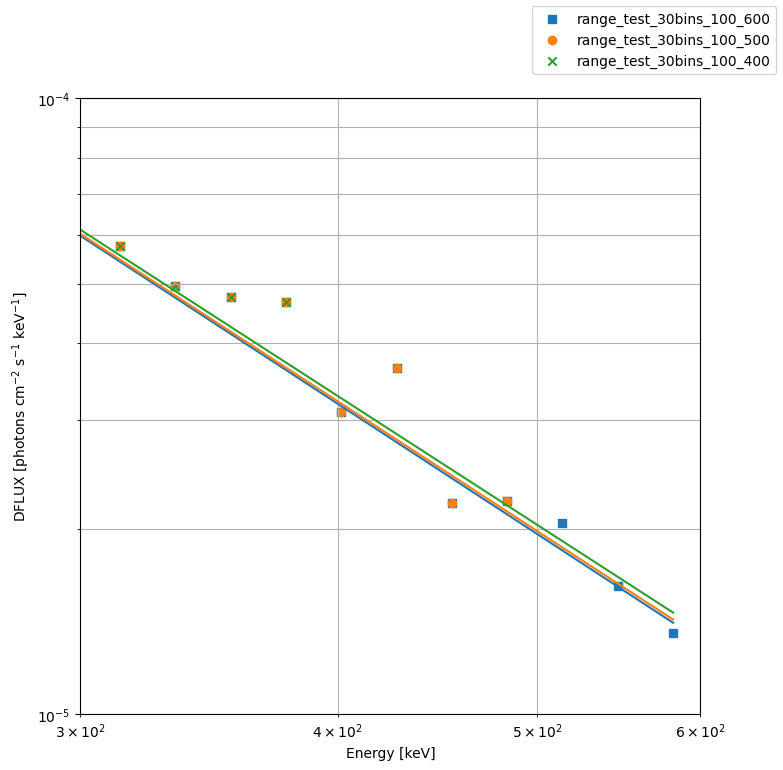

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.grid(which='both', axis='both')
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel(r"Energy [keV]")
ax.set_ylabel(r"DFLUX [photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")

bins_middle = generate_Ebins(30, [100, 600])[:-1] + np.diff(generate_Ebins(30, [100, 600])) / 2


m = ['s', 'o', 'x', '^', 'D', 'v', '<', '>', 'p', '*']

for i,name in enumerate(names):
    val = np.loadtxt(path + name + "_smf_SE" + "/fit_val.txt")
    print(val)

    ax.plot(bins_middle, powerlaw(bins_middle, *val))
    ax.scatter(bins_middle, Dflux[i], label=name, marker=m[i])

    if i == 2: break

ax.set_xlim([300, 600])
ax.set_ylim([1e-5, 1e-4])

fig.legend()

### changing the lower energy boundary

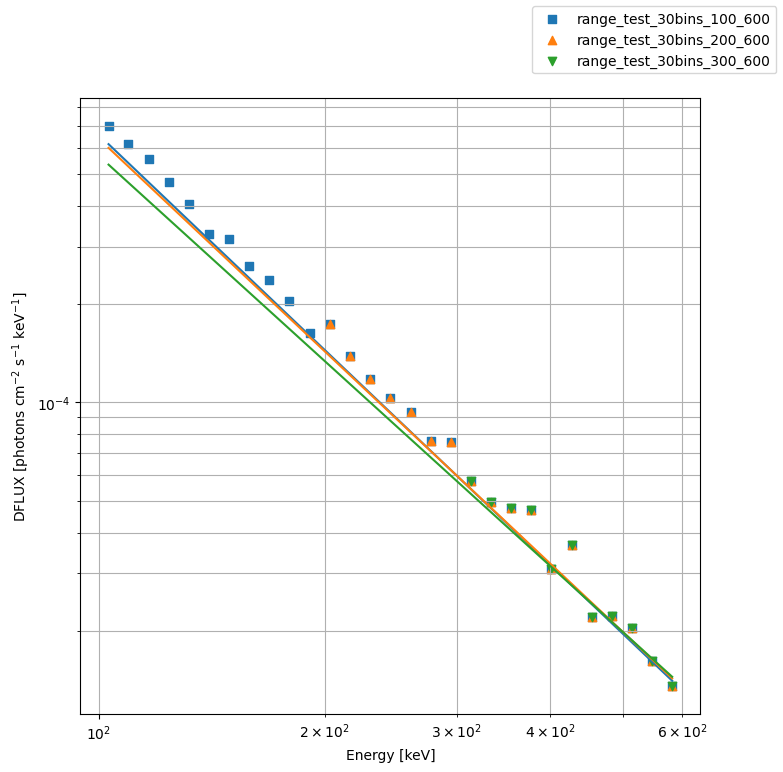

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.grid(which='both', axis='both')
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel(r"Energy [keV]")
ax.set_ylabel(r"DFLUX [photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")

take = [0, 3, 5]

bins_middle = generate_Ebins(30, [100, 600])[:-1] + np.diff(generate_Ebins(30, [100, 600])) / 2


m = ['s', 'o', 'x', '^', 'D', 'v', '<', '>', 'p', '*']

for i,name in enumerate(names):
    if i in take:
        val = np.loadtxt(path + name + "_smf_SE" + "/fit_val.txt")

        ax.plot(bins_middle, powerlaw(bins_middle, *val))
        ax.scatter(bins_middle, Dflux[i], label=name, marker=m[i])

    

# ax.set_xlim([300, 600])
# ax.set_ylim([1e-5, 1e-4])

fig.legend()

In [40]:
names

array(['range_test_30bins_100_600', 'range_test_30bins_100_500',
       'range_test_30bins_100_400', 'range_test_30bins_200_600',
       'range_test_30bins_200_500', 'range_test_30bins_300_600'],
      dtype='<U25')